# Gaussian Noise and the Central Limit Theorem

Based on https://gregorygundersen.com/blog/2019/02/01/clt/

In [185]:
import numpy as np
import matplotlib.pyplot as plt

In [186]:
plt.rcParams.update({
        'axes.grid': False,
        'axes.labelsize': 12,
        'axes.linewidth': 0.8,
        'axes.titlesize': 12,
        'font.size': 10,
        'legend.fontsize': 12,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12,
        'font.family': 'serif',
        'font.sans-serif': ['Bitstream Vera Sans'],
        'font.serif': ['Times New Roman'],
        'text.latex.preamble': r'\usepackage{amsmath} \usepackage{amssymb} \usepackage{amsfonts}',
        'text.usetex': True,
        'patch.force_edgecolor': True,
        'figure.dpi': 100,
        'savefig.dpi': 100,
    }
)

## Gaussian Noise

In GW data analysis, we assume that the detector noise can be modelled as Gaussian. This means that for each data sample in the time/frequency domain (since the Fourier transform of a Gaussian is another Gaussian), the noise content is randomly sampled from a Gaussian distribution. In other words, if we choose a sampling frequency, $f$, then at each timestep, $t_{i+1} = t_i + \Delta t$, (where $\Delta t = f^{-1}$) we take a measurement:

$d_{t_0} = s_{t_0} + n_{t_0}$

$d_{t_0+\Delta t} = s_{t_0+\Delta t} + n_{t_0+\Delta t}$

$d_{t_0+2\Delta t} = s_{t_0+2\Delta t} + n_{t_0+2\Delta t}$

The probability of obtaining a noise measurement $n_{t_0+i\Delta t}$ is given by a Gaussian, i.e. $P(n_{t_0+i\Delta t}) \sim \mathcal{N}$.

In [187]:
# Define sampling frequency and duration of GW signal

f = 4096 # Sampling frequency (Hz)
duration = 4 # Duration of GW signal (s)

total_samples = f * duration  # Total number of data samples

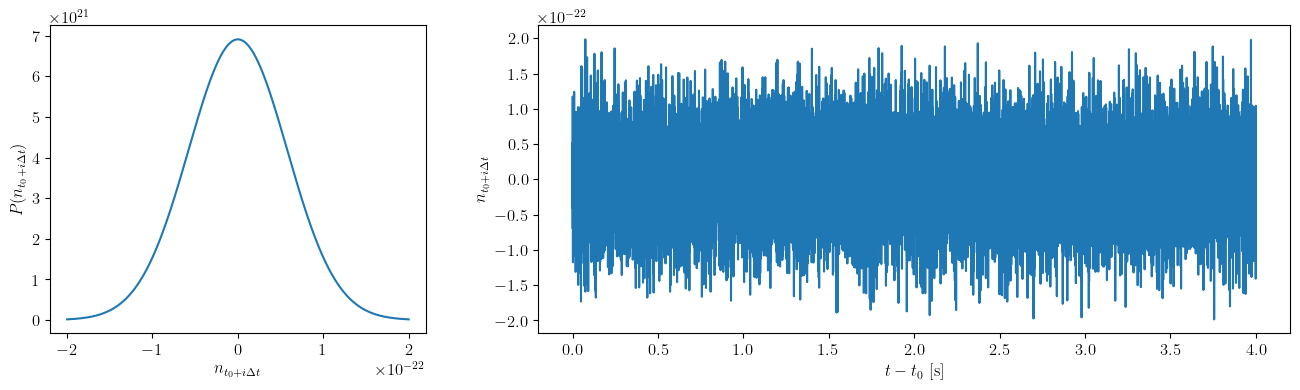

In [188]:
fig, ax = plt.subplots(1, 2, figsize=(16,4), gridspec_kw={'width_ratios': [1, 2]})

# Define a Gaussian distribution with mean 0 and standard deviation of a uniform distribution between -1e-22 and 1e-22

mu = 0
sigma = np.sqrt(1/12)*(1e-22 - (-1e-22))

x = np.linspace(-2e-22, 2e-22, 1000)
pdf = scipy.stats.norm.pdf(x, mu, sigma)

ax[0].set_xlabel(r'$n_{t_0+i\Delta t}$')
ax[0].set_ylabel(r'$P(n_{t_0+i\Delta t})$')
ax[0].plot(x, pdf)

# Generate samples from the Gaussian distribution to simulate noise

samples = np.random.choice(x, size=total_samples, p=pdf/np.sum(pdf))

ax[1].plot(np.array(range(len(samples)))/f, samples)
ax[1].set_xlabel(r'$t - t_0$ [s]')
ax[1].set_ylabel(r'$n_{t_0+i\Delta t}$')

plt.show()

## Central Limit Theorem

Let's say we have multiple noise sources, e.g. seismic activity, environmental factors, shot noise, etc. Let's assume that value of the noise produced by each source, $X_i$, can be modelled by a uniform distribution, i.e. $P(X_i) \sim \mathcal{U}$, where $i \in \{\mathrm{seismic, env, shot, ...}\}$. The sum of the noise contributions at each point in the timeseries will then be given by

$X = X_\mathrm{seismic} + X_\mathrm{env} + X_\mathrm{shot} + ... = \sum_{i=1}^{N} X_i$

where N is the total number of noise sources. 

The Central Limit Theorem states that if we take the limit $N \rightarrow \infty$ of

$S_N = \frac{1}{N} \sum_{i=1}^{N} X_i$

then the distribution 

$\sqrt{N}(S_N - \mu) \sim \mathcal{N}(0,\sigma^2)$

where $\mu = \mathbb{E}(X)$ and $\sigma = \sqrt{\mathrm{Var}(X)}$ 

Therefore, from above we have that our noise profile should also follow a Gaussian distribution. In other words, at a given timestep we draw a noise measurement (which is a combination of all possible noise sources) from a Gaussian.


In [189]:
def sN(N):

    random_numbers = []

    for i in range(N):
        rand = np.random.uniform(-1e-22, 1e-22)
        random_numbers.append(rand)

    return np.sum(random_numbers)/N

Since $P(X_i) \sim \mathcal{U}(a,b)$, $\mu = \frac{1}{2}(a+b)$ and $\sigma = \sqrt{\frac{1}{12}(b-a)^2}$

In [190]:
mu = 1/2*(-1e-22 + 1e-22) # Mean of uniform distribution
sigma = np.sqrt(1/12*(1e-22 - (-1e-22))**2) # Standard deviation of uniform distribution

x = np.linspace(-2e-22, 2e-22, 1000)
pdf = scipy.stats.norm.pdf(x, mu, sigma)

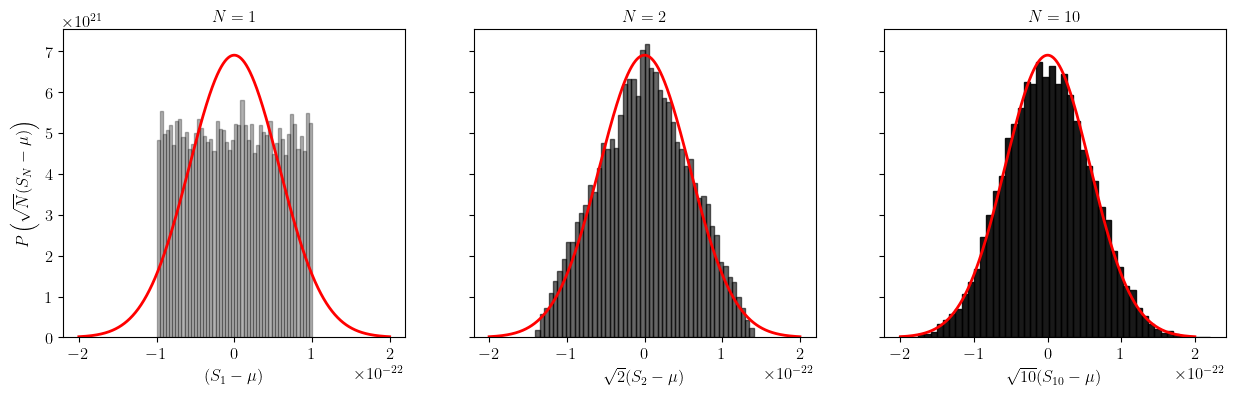

In [191]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

# N = number of noise sources

N = 1
samples = np.array([])
for i in range(total_samples):
    samples = np.append(samples, sN(N))

# density=True normalises the histogram
axes[0].hist(np.sqrt(N)*(samples - mu), bins=50, density=True, color='k', alpha=0.3)
axes[0].plot(x, pdf, color='r', lw=2)
axes[0].set_ylabel(r'$P\left(\sqrt{N}(S_N-\mu)\right)$')
axes[0].set_xlabel(r'$(S_1-\mu)$')
axes[0].set_title(r'$N=1$')

N = 2
samples = np.array([])
for i in range(total_samples):
    samples = np.append(samples, sN(N))

axes[1].hist(np.sqrt(N)*(samples - mu), bins=50, density=True, color='k', alpha=0.6)
axes[1].set_xlabel(r'$\sqrt{2}(S_2-\mu)$')
axes[1].plot(x, pdf, color='r', lw=2)
axes[1].set_title(r'$N=2$')

N = 10
samples = np.array([])
for i in range(total_samples):
    samples = np.append(samples, sN(N))

axes[2].hist(np.sqrt(N)*(samples - mu), bins=50, density=True, color='k', alpha=0.9)
axes[2].set_xlabel(r'$\sqrt{10}(S_{10}-\mu)$')
axes[2].plot(x, pdf, color='r', lw=2)
axes[2].set_title(r'$N=10$')

plt.show()

Above, we discussed the central limit theorem. Below, the same concept holds. However, in GW data analysis, the noise contributions are purely additive (no weighting by N or $\sigma$) so we just plot the distribution of $S_N$

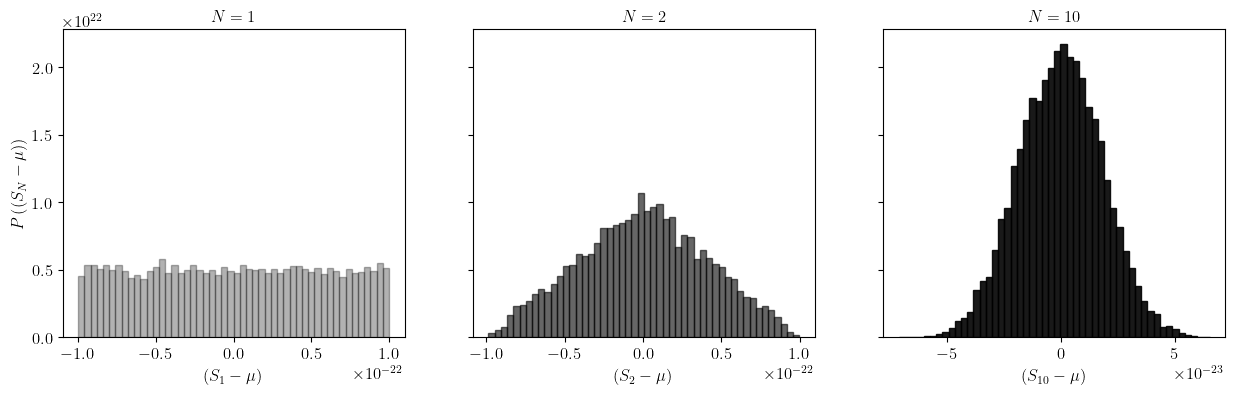

In [192]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

# N = number of noise sources

N = 1
samples = np.array([])
for i in range(total_samples):
    samples = np.append(samples, sN(N))

# density=True normalises the histogram
axes[0].hist((samples - mu), bins=50, density=True, color='k', alpha=0.3)
axes[0].set_ylabel(r'$P\left((S_N-\mu)\right)$')
axes[0].set_xlabel(r'$(S_1-\mu)$')
axes[0].set_title(r'$N=1$')

N = 2
samples = np.array([])
for i in range(total_samples):
    samples = np.append(samples, sN(N))

axes[1].hist((samples - mu), bins=50, density=True, color='k', alpha=0.6)
axes[1].set_xlabel(r'$(S_2-\mu)$')
axes[1].set_title(r'$N=2$')

N = 10
samples = np.array([])
for i in range(total_samples):
    samples = np.append(samples, sN(N))

axes[2].hist((samples - mu), bins=50, density=True, color='k', alpha=0.9)
axes[2].set_xlabel(r'$(S_{10}-\mu)$')
axes[2].set_title(r'$N=10$')

plt.show()